# **Data Analysis Project - Unicorn Companies**

The following project performs the data analysis process on a dataset called 'Unicorn_Companies'. A unicorn company in this context is a private company with a valuation over $1 billion.

This project will include the following:

- Exploring the dataset
- Cleaning the data
- Validating the data
- Structuring the data
- Visualising the data with a variety of graphs
- Creating a dashboard
- Communicating insights discovered

Firstly, all required libraries and packagies will be imported.

In [41]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

Let's now import the dataset.

In [2]:
df = pd.read_csv('Unicorn_Companies.csv')

## **Exploratory Data Analysis (EDA)**

### **Data Exploration**

We will first do some initial exploration to understand the nature of the dataset.

In [3]:
df.head(10)

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors
0,Bytedance,$180B,4/7/17,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$100B,12/1/12,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100B,7/3/18,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95B,1/23/14,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG"
4,Klarna,$46B,12/12/11,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita..."
5,Canva,$40B,1/8/18,Internet software & services,Surry Hills,Australia,Oceania,2012,$572M,"Sequoia Capital China, Blackbird Ventures, Mat..."
6,Checkout.com,$40B,5/2/19,Fintech,London,United Kingdom,Europe,2012,$2B,"Tiger Global Management, Insight Partners, DST..."
7,Instacart,$39B,12/30/14,"Supply chain, logistics, & delivery",San Francisco,United States,North America,2012,$3B,"Khosla Ventures, Kleiner Perkins Caufield & By..."
8,JUUL Labs,$38B,12/20/17,Consumer & retail,San Francisco,United States,North America,2015,$14B,Tiger Global Management
9,Databricks,$38B,2/5/19,Data management & analytics,San Francisco,United States,North America,2013,$3B,"Andreessen Horowitz, New Enterprise Associates..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Company           1074 non-null   object
 1   Valuation         1074 non-null   object
 2   Date Joined       1074 non-null   object
 3   Industry          1074 non-null   object
 4   City              1058 non-null   object
 5   Country/Region    1074 non-null   object
 6   Continent         1074 non-null   object
 7   Year Founded      1074 non-null   int64 
 8   Funding           1074 non-null   object
 9   Select Investors  1073 non-null   object
dtypes: int64(1), object(9)
memory usage: 84.0+ KB


We can see that the 'Valuation' and 'Funding' columns are strings and not numeric.

In [5]:
df.describe(include='all')

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors
count,1074,1074,1074,1074,1058,1074,1074,1074.000000,1074,1073
unique,1073,30,639,16,256,46,6,NaN,539,1058
top,Bolt,$1B,7/13/21,Fintech,San Francisco,United States,North America,NaN,$1B,Sequoia Capital
freq,2,471,9,224,152,562,589,NaN,60,3
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012.895717,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.698573,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1919.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,NaN,NaN


Since there are so many categorical variables, it is difficult to analyse many of the columns.

### **Data Cleaning**

Let's check for missing values.

In [6]:
df.isnull().sum()

,0
Company,0
Valuation,0
Date Joined,0
Industry,0
City,16
Country/Region,0
Continent,0
Year Founded,0
Funding,0
Select Investors,1


There is one missing value in the 'Select Investors' column. This seems reasonable as the comapny may have gained unicorn status with no external investments.

There are also 16 missing values in the 'City' column. This does not look reasonable and should be investigated further.

Let's now have a closer look at the rows with the missing 'City' values to discover what might be causing this.

In [7]:
df[df['City'].isnull()]

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors
12,FTX,$32B,7/20/21,Fintech,NaN,Bahamas,North America,2018,$2B,"Sequoia Capital, Thoma Bravo, Softbank"
170,HyalRoute,$4B,5/26/20,Mobile & telecommunications,NaN,Singapore,Asia,2015,$263M,Kuang-Chi
242,Moglix,$3B,5/17/21,E-commerce & direct-to-consumer,NaN,Singapore,Asia,2015,$471M,"Jungle Ventures, Accel, Venture Highway"
251,Trax,$3B,7/22/19,Artificial intelligence,NaN,Singapore,Asia,2010,$1B,"Hopu Investment Management, Boyu Capital, DC T..."
325,Amber Group,$3B,6/21/21,Fintech,NaN,Hong Kong,Asia,2015,$328M,"Tiger Global Management, Tiger Brokers, DCM Ve..."
382,Ninja Van,$2B,9/27/21,"Supply chain, logistics, & delivery",NaN,Singapore,Asia,2014,$975M,"B Capital Group, Monk's Hill Ventures, Dynamic..."
541,Advance Intelligence Group,$2B,9/23/21,Artificial intelligence,NaN,Singapore,Asia,2016,$536M,"Vision Plus Capital, GSR Ventures, ZhenFund"
811,Carousell,$1B,9/15/21,E-commerce & direct-to-consumer,NaN,Singapore,Asia,2012,$288M,"500 Global, Rakuten Ventures, Golden Gate Vent..."
848,Matrixport,$1B,6/1/21,Fintech,NaN,Singapore,Asia,2019,$100M,"Dragonfly Captial, Qiming Venture Partners, DS..."
880,bolttech,$1B,7/1/21,Fintech,NaN,Singapore,Asia,2018,$210M,"Mundi Ventures, Doqling Capital Partners, Acti..."


This explains almost all the missing values. Singapore is considered both a city and a country, and 'Hong Kong' may also be considered a country in some contexts. The Bahamas entry does seem to have a legitimate missing value.

Let's leave these missing values as they are since they are not detrimentral to the dataset.

Let's now check for duplicate data.

In [8]:
df.duplicated().sum()

np.int64(0)

There are no duplicates so we can move on.

### **Data Validation**

Let's check the class labels for some of the variables to determine is there are any inconsistencies.

In [9]:
df['Industry'].unique()

array(['Artificial intelligence', 'Other',
       'E-commerce & direct-to-consumer', 'Fintech',
       'Internet software & services',
       'Supply chain, logistics, & delivery', 'Consumer & retail',
       'Data management & analytics', 'Edtech', 'Health', 'Hardware',
       'Auto & transportation', 'Travel', 'Cybersecurity',
       'Mobile & telecommunications', 'Artificial Intelligence'],
      dtype=object)

We can see that 'Artifical intelligence' has two options; one with a lowercase 'i' and one with a uppercase 'I'.

This can be resolved by replacing one of the columns.

In [10]:
df['Industry'] = df['Industry'].replace({'Artificial Intelligence':'Artificial intelligence'})

In [11]:
df['Industry'].unique()

array(['Artificial intelligence', 'Other',
       'E-commerce & direct-to-consumer', 'Fintech',
       'Internet software & services',
       'Supply chain, logistics, & delivery', 'Consumer & retail',
       'Data management & analytics', 'Edtech', 'Health', 'Hardware',
       'Auto & transportation', 'Travel', 'Cybersecurity',
       'Mobile & telecommunications'], dtype=object)

They are now consistent.

In [12]:
df['City'].unique()

array(['Beijing', 'Hawthorne', 'Shenzhen', 'San Francisco', 'Stockholm',
       'Surry Hills', 'London', 'Cary', nan, 'Jacksonville', 'Bengaluru',
       'Jakarta', 'Shanghai', 'Philadelphia', 'Waltham', 'New York',
       'Pittsburgh', 'Istanbul', 'San Diego', 'Roseville', 'Changsha',
       'Tallinn', 'Luohe', 'Munich', 'Gurugram', 'Boston', 'Glendale',
       'Cheung Sha Wan', 'Walpole', 'Seoul', 'Fremont', 'Mountain View',
       'Lerma de Villada', 'Berlin', 'Kirkland', 'Mumbai', 'Santa Clara',
       'Vancouver', 'San Jose', 'San Mateo', 'Irving', 'Chicago',
       'Redwood City', 'Hoboken', 'Palo Alto', 'Toronto', 'Los Angeles',
       'Hangzhou', 'Changzhou', 'Melbourne', 'Amsterdam', 'Paris',
       'Oakland', 'Brooklyn', 'Helsinki', 'Burlingame', 'Tel Aviv',
       'Zhuhai', 'Guangzhou', 'Vilnius', 'Irvine', 'Copenhagen',
       'Brussels', 'Bogota', 'Sao Paulo', 'Atlanta', 'Campinas',
       'Montreal', 'Bellevue', 'Gurgaon', 'Noida', 'Suzhou', 'El Segundo',
       'Faridaba

In [13]:
df['Country/Region'].unique()

array(['China', 'United States', 'Sweden', 'Australia', 'United Kingdom',
       'Bahamas', 'India', 'Indonesia', 'Turkey', 'Estonia', 'Germany',
       'Hong Kong', 'South Korea', 'Mexico', 'Canada', 'Netherlands',
       'France', 'Finland', 'Israel', 'Lithuania', 'Denmark', 'Belgium',
       'Colombia', 'Brazil', 'Singapore', 'Austria', 'Ireland',
       'United Arab Emirates', 'Switzerland', 'Vietnam', 'South Africa',
       'Thailand', 'Norway', 'Chile', 'Argentina', 'Bermuda', 'Japan',
       'Spain', 'Malaysia', 'Senegal', 'Philippines', 'Luxembourg',
       'Nigeria', 'Czech Republic', 'Croatia', 'Italy'], dtype=object)

In [14]:
df['Continent'].unique()

array(['Asia', 'North America', 'Europe', 'Oceania', 'South America',
       'Africa'], dtype=object)

The other columns also contain consistent values.

### **Data Structuring**

Firstly lets fix convert the 'Valuation' and 'Funding' to numeric.

The 'Valuation' column is not that difficult, we just need to remove the '$' and 'B' to convert to numeric.

In [15]:
df['Valuation'] = df['Valuation'].str.replace('$', '')
df['Valuation'] = df['Valuation'].str.replace('B', '')
df['Valuation'] = df['Valuation'].astype('int')

The 'Funding' column is a little more difficult. We need to remove the '$' at the start and remove any rows where the value is unknown. We then need to remove the 'B' and 'M' from the end and multiply the value by 1,000 if it in billions.

In [16]:
df['Funding'] = df['Funding'].str.replace('$', '')

In [17]:
df = df[df['Funding'] != 'Unknown']

In [18]:
df['Funding'] = df['Funding'].str[:-1].astype('int') * df['Funding'].str[-1].map({'M':1,'B':1000})

Let's now rename the columns to ensure they are understandable.

In [19]:
df = df.rename(columns={'Valuation':'Valuation (B)', 'Funding':'Funding (M)'})

We can now check that the operation was performed successfully.

In [20]:
df.dtypes

,0
Company,object
Valuation (B),int64
Date Joined,object
Industry,object
City,object
Country/Region,object
Continent,object
Year Founded,int64
Funding (M),int64
Select Investors,object


Let's now convert the 'Date Joined' to a datetime object. This will streamline the process of working with time.

In [21]:
df['Date Joined'] = pd.to_datetime(df['Date Joined'])

/tmp/ipykernel_5227/2593295292.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Joined'] = pd.to_datetime(df['Date Joined'])


Lets now create a year column and a quarter colum. We will then drop the 'Date Joined' colum as we no longer need it.

In [22]:
df['Year Joined'] = df['Date Joined'].dt.year
df['Quarter'] = df['Date Joined'].dt.quarter

df = df.drop('Date Joined', axis=1)

Finally, lets remove the 'Select Investors' column since this won't be needed in the analysis.

In [23]:
df = df.drop('Select Investors', axis=1)

We can also create a variable that tells us how many years a company took to become a unicorn.

In [24]:
df['Time Taken'] = df['Year Joined'] - df['Year Founded']

We can now have a look at our data and it's datatypes to confirm everything has been successfully completed.

In [25]:
df.dtypes

,0
Company,object
Valuation (B),int64
Industry,object
City,object
Country/Region,object
Continent,object
Year Founded,int64
Funding (M),int64
Year Joined,int32
Quarter,int32


Everything looks good, so we can move on to the next step.

## **Data Visualisation and Analysis**

Let's start exploring the data through visualisations. We can then use these visualisations to analyse the data and gain insights.

Let's start with some boxplots and histograms to understand the distribution of the data.

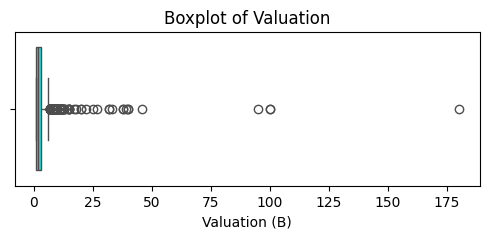

In [161]:
plt.figure(figsize=(6, 2))
sns.boxplot(x=df['Valuation (B)'], color='cyan')
plt.title('Boxplot of Valuation')
plt.show()

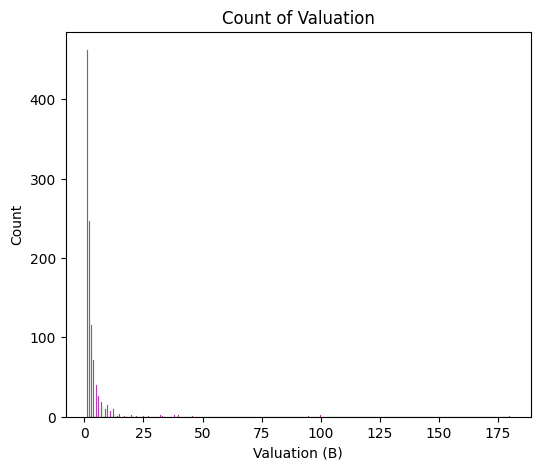

In [156]:
plt.figure(figsize=(6, 5))
sns.histplot(df['Valuation (B)'], color='m')
plt.title('Count of Valuation')
plt.show()

There are some very strong outliers in the 'Valuation' column. A majority of comapnies are on the lower end with a key few having a much higher value than the rest.

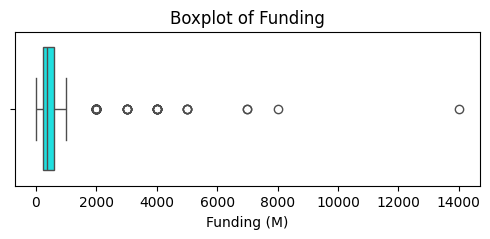

In [162]:
plt.figure(figsize=(6, 2))
sns.boxplot(x=df['Funding (M)'], color='cyan')
plt.title('Boxplot of Funding')
plt.show()

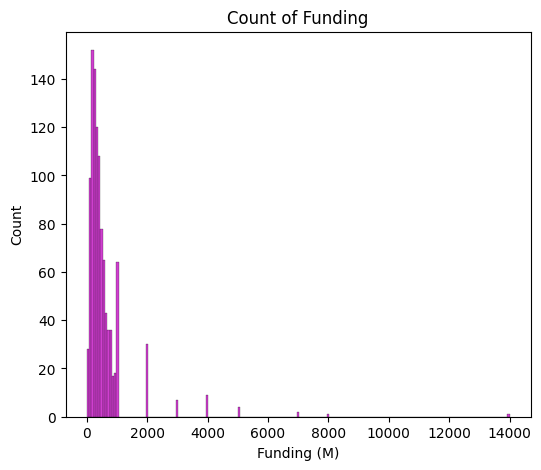

In [160]:
plt.figure(figsize=(6, 5))
sns.histplot(df['Funding (M)'], color='m')
plt.title('Count of Funding')
plt.show()

There also seem to be outliers in the 'Funding' column, however these are not as extreme as the outliers observed in the 'Valuation' column.

Let's now create a pie chart of continents. We first need to create a dataframe which contains the data we would like to present.

In [176]:
df_continent = df[['Continent', 'Company']].groupby(by='Continent').count()
df_continent.head()

,Company
Continent,
Africa,3
Asia,307
Europe,142
North America,581
Oceania,8


Text(0.5, 1.0, 'Percentage of Companies by Continent')

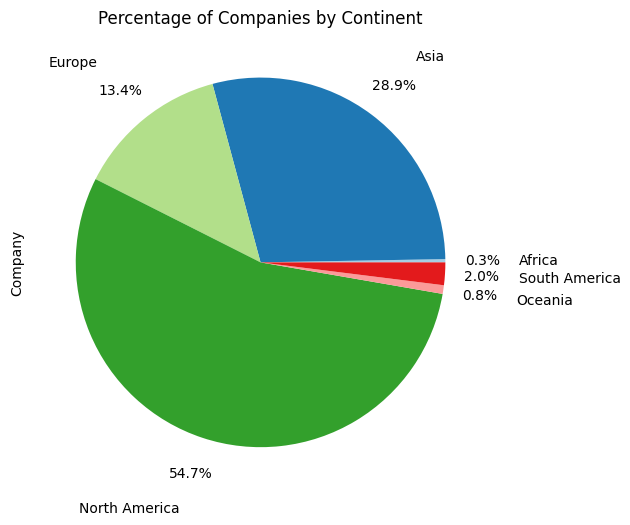

In [193]:
plt.figure(figsize=(6,6))
df_continent['Company'].plot(kind='pie', autopct='%1.1f%%', pctdistance=1.2, labeldistance=1.4, textprops={'fontsize':10}, colors=plt.cm.Paired.colors)
plt.title('Percentage of Companies by Continent')

The major of comapnies are from North America, with Asia in second place following by Europe in third place. South America, Oceana and Africa only make up 3.1% combined.

Next we can create some bar charts to understand the valuation by industry and by year founded.

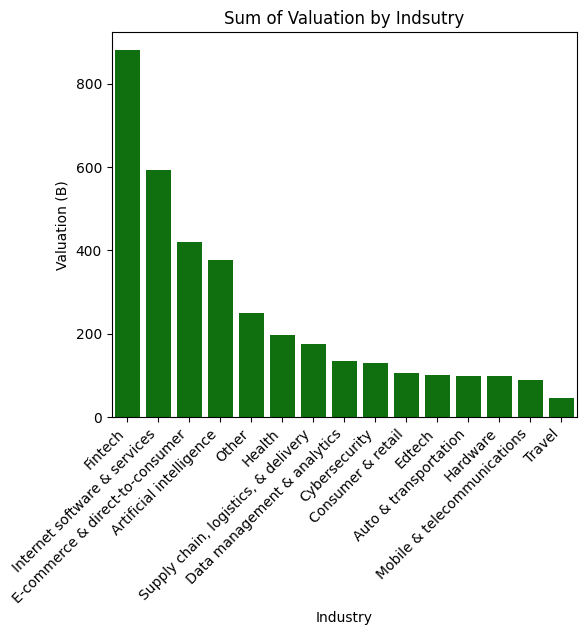

In [177]:
df_grouped = pd.DataFrame(df.groupby(by='Industry')['Valuation (B)'].sum().sort_values(ascending=False))

plt.figure(figsize=(6, 5))
sns.barplot(data=df_grouped, x='Industry', y='Valuation (B)', errorbar=None, color='green')
plt.xticks(rotation = 45, ha='right')
plt.title('Sum of Valuation by Indsutry')
plt.show()

When we group the companies by industry and sum their valuations, we can see that Fintech stands out on top. Internet software and services is in second place, following by E-commerce and Artificial intelligence in third and fourth place respectively. Travel is the worst performing industry in this dataset.

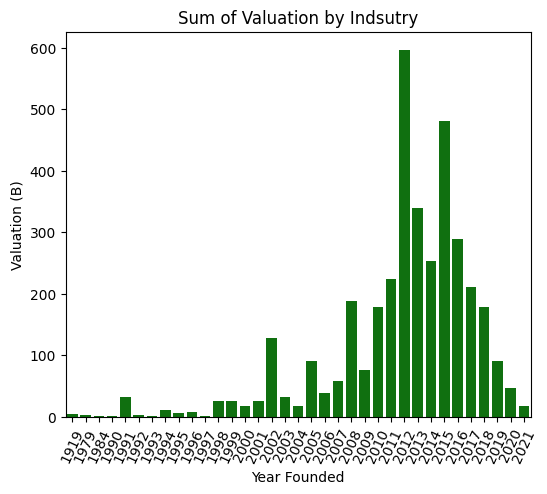

In [178]:
df_grouped2 = pd.DataFrame(df.groupby(by='Year Founded')['Valuation (B)'].sum().sort_values(ascending=False))

plt.figure(figsize=(6, 5))
sns.barplot(data=df_grouped2, x='Year Founded', y='Valuation (B)', errorbar=None, color='green')
plt.xticks(rotation = 65)
plt.title('Sum of Valuation by Indsutry')
plt.show()

The most popular years for unicorn companies to be founed are between 2012 and 2016. There also exists a company that was founded in 1919, which is by far the oldest company in the dataset.

We can now plot the number of companies that joined unicorn status each quarter.

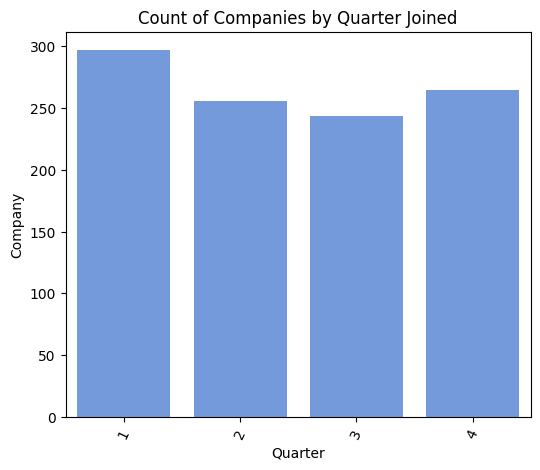

In [181]:
df_grouped3 = pd.DataFrame(df[['Quarter', 'Company']].groupby(by='Quarter').count())

plt.figure(figsize=(6, 5))
sns.barplot(data=df_grouped3, x='Quarter', y='Company', errorbar=None, color='cornflowerblue')
plt.xticks(rotation = 65)
plt.title('Count of Companies by Quarter Joined')
plt.show()

There is no obvious pattern here, however you could say that more companies became unicorns in Q1 compared to any other quarter.

Let's now create a scatterplot between funding and valuation to see if there is any relationship between the two.

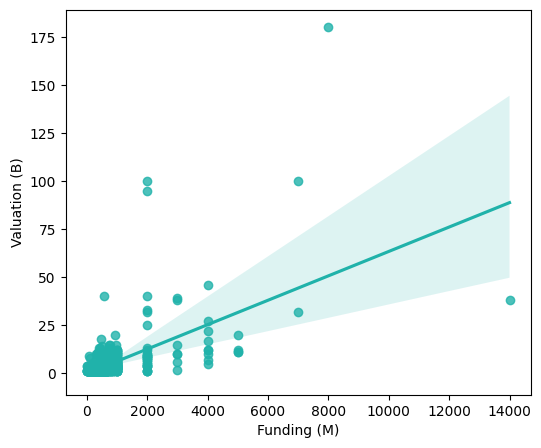

In [197]:
plt.figure(figsize=(6, 5))
sns.regplot(data=df, x='Funding (M)', y='Valuation (B)', color='lightseagreen')
plt.show()

There does seem to be somewhat of a relashionship between funding and valuation, however the relationship isn't obvious or strong.

Which industries have companies that take the least amount of time to become unicorns? We will find out with our next plot.

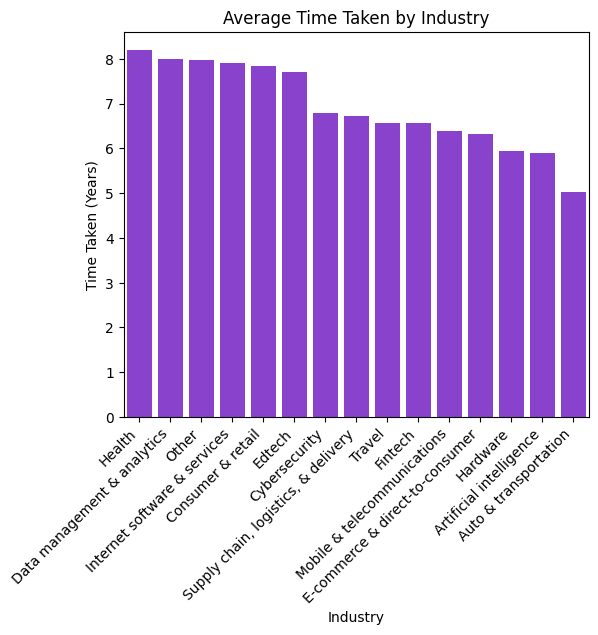

In [189]:
df_grouped4 = pd.DataFrame(df.groupby(by='Industry')['Time Taken'].mean().sort_values(ascending=False))

plt.figure(figsize=(6, 5))
sns.barplot(data=df_grouped4, x='Industry', y='Time Taken', errorbar=None, color='blueviolet')
plt.xticks(rotation = 45, ha='right')
plt.ylabel('Time Taken (Years)')
plt.title('Average Time Taken by Industry')
plt.show()

Companies in the health industry seems to take the longest amount of time to reach unicorn status. Auto & Transportation seems to take the least amount of time.

Let's now create a map to visualse which countries have the highest combined valuations.

In [97]:
df_countries = pd.DataFrame(df[['Country/Region', 'Valuation (B)']].groupby(by='Country/Region').sum())

px.choropleth(df_countries, locations=df_countries.index, locationmode='country names', color = 'Valuation (B)', color_continuous_scale='blues', width = 1000, height = 550)

It's pretty clear to see that the United States has the highest combined company value. The issue is that this makes it difficult to assess the other countries. Let's try to remove the top few countries and re-create the graph.

In [66]:
df_countries = pd.DataFrame(df[['Country/Region', 'Valuation (B)']].groupby(by='Country/Region').sum()).sort_values(by='Valuation (B)', ascending=False)
df_countries

,Valuation (B)
Country/Region,
United States,1924
China,693
India,196
United Kingdom,195
Germany,72
Sweden,63
Australia,56
France,54
Canada,45


Let's remove the top four countries.

In [68]:
df_countries_no4 = pd.DataFrame(df[['Country/Region', 'Valuation (B)']].groupby(by='Country/Region').sum()).sort_values(by='Valuation (B)', ascending=False).iloc[4:, :]

,Valuation (B)
Country/Region,
Germany,72
Sweden,63
Australia,56
France,54
Canada,45
South Korea,41
Israel,39
Brazil,37
Bahamas,32


In [78]:
px.choropleth(df_countries_no4, locations=df_countries_no4.index, locationmode='country names', color = 'Valuation (B)', color_continuous_scale='Blues', width = 1000, height = 550)

This makes it easier to visualise the rest of the countries. We can see that Germany, Sweden, France, Australia and Canada are pretty high up on the list. An investor looking at this map may consider these countries as good investment destinations due to their history of success.

How about we visualise the countries with the lowest funding. We will multiply the funding by negative 1 so that the map highlights the lowest funded countries.

In [98]:
df_countries_low_funding = pd.DataFrame(df[['Country/Region', 'Funding (M)']].groupby(by='Country/Region').sum())
df_countries_low_funding['Funding (M)'] = df_countries_low_funding['Funding (M)'] * -1

px.choropleth(df_countries_low_funding, locations=df_countries_low_funding.index, locationmode='country names', color = 'Funding (M)', color_continuous_scale='Teal', width = 1000, height = 550)

Once again the top countries are dominating the graph. Removing these countires might help in creating a visualisation that is easier to interpret.

In [99]:
df_countries_low_funding_no4 = pd.DataFrame(df[['Country/Region', 'Funding (M)']].groupby(by='Country/Region').sum()).sort_values(by='Funding (M)', ascending=False).iloc[4:, :]
df_countries_low_funding_no4['Funding (M)'] = df_countries_low_funding_no4['Funding (M)'] * -1

px.choropleth(df_countries_low_funding_no4, locations=df_countries_low_funding_no4.index, locationmode='country names', color = 'Funding (M)', color_continuous_scale='Teal', width = 1000, height = 550)

We can see that Germany, Sweden and France (countries mentioned earlier) get quite a lot of funding from a relative perspective. However, we can see that Australia and Canada don't receive much funding (relatively), even though they have many valuable companies. Using this information, an investor could conclude that Australia and Canada may present ideal investments destinations.

### **Dashboard**

Let's now create a dashboard with a selection of four graphs.

/tmp/ipykernel_5227/3765071081.py:5: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_5227/3765071081.py:14: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



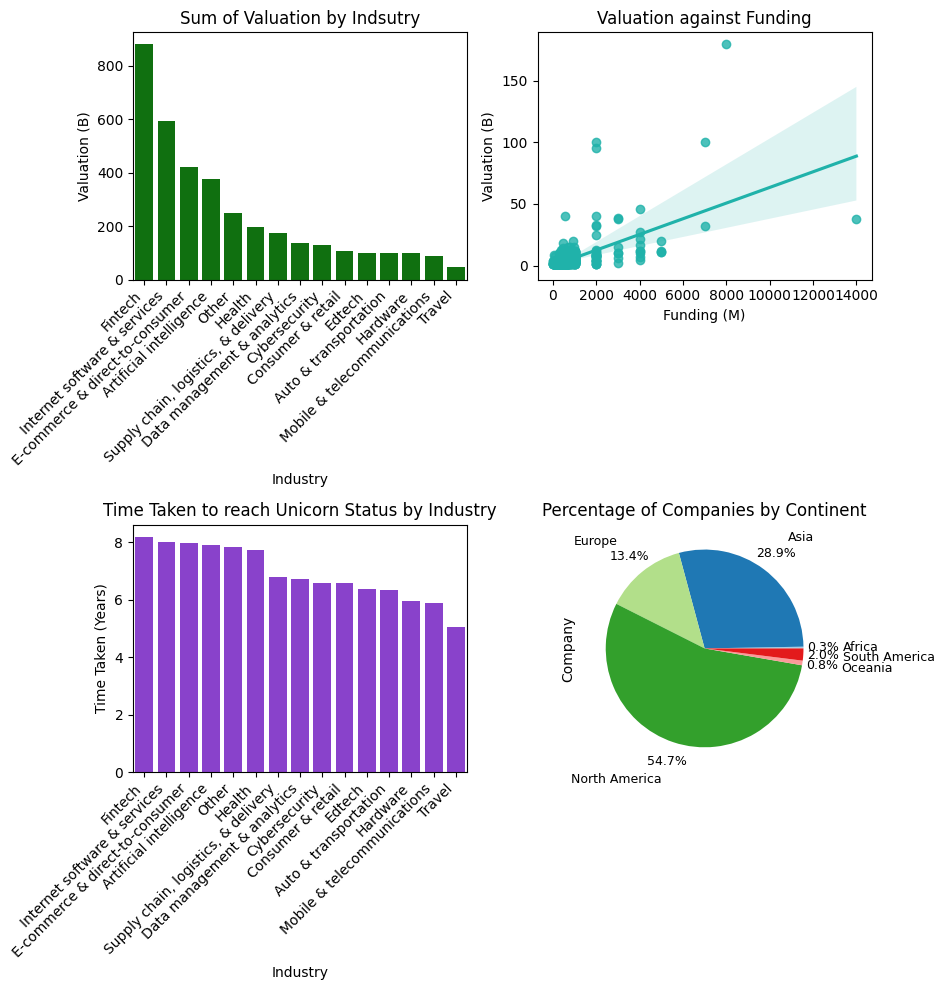

In [199]:
fig = plt.figure(figsize = (10, 10))

ax1 = fig.add_subplot(2, 2, 1)
sns.barplot(data=df_grouped, x='Industry', y='Valuation (B)', errorbar=None, color='green', ax=ax1)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation = 45, ha='right')
ax1.set_title('Sum of Valuation by Indsutry')

ax2 = fig.add_subplot(2, 2, 2)
sns.regplot(data=df, x='Funding (M)', y='Valuation (B)', color='lightseagreen', ax=ax2)
ax2.set_title('Valuation against Funding')

ax3 = fig.add_subplot(2, 2, 3)
sns.barplot(data=df_grouped4, x='Industry', y='Time Taken', errorbar=None, color='blueviolet', ax=ax3)
ax3.set_xticklabels(ax1.get_xticklabels(), rotation = 45, ha='right')
ax3.set_ylabel('Time Taken (Years)')
ax3.set_title('Time Taken to reach Unicorn Status by Industry')

ax4 = fig.add_subplot(2, 2, 4)
df_continent['Company'].plot(kind='pie', autopct='%1.1f%%', pctdistance=1.2, labeldistance=1.4, textprops={'fontsize':9}, colors=plt.cm.Paired.colors, ax=ax4)
ax4.set_title('Percentage of Companies by Continent')

plt.tight_layout()
plt.show()


## **Insights**

The following insights were gathered from the analysis:

- Valuations are heavily left-skewed, meaning a majoring of companies dominated the top.
- Funding is also heavily left-skewed, although not as much as valuations.
- North America makes up 54.7% of combined company valuation, with Asia at 28.9% and Europe at 13.4%. Africa, South America and Oceana only made up 3.1% combined.
- Fintech is the industry with the highest combined valuation (over 800 billion), followed by Internet software & services in second, E-commerce in third and Artificial Intelligence in forth place.
- Travel was the industry with the lowest combined company valuation.
- The most popular years for unicorn companies to be founded are 2012 to 2016.
- There does seem to be somewhat of a relationship between funding and valuation, however the relationship isn't obvious or strong.
- Companies in the health industry take the longest amount of time to reach unicorn status (over 8 years), whilst companies in the Auto & Transportation industry take the least (5 years).
- There are four countries that dominate the market (United States, China, India and United Kingdom).
- Germany, Sweden and France have high combined company valuations, however also have relatively high funding.
- Australia and Canada have high combined company valuations, but with relatively low funding (presenting a potential opportunity).

## **Summary**


This project performs the data analysis process on the Unicorn Companies dataset.

The following was performed in the project:

- Exploration
- Cleaning
- Validating
- Structuring
- Visualising
- Dashboard creation
- Communication of insights